LINEAR REGRESSION: Tumor Size → Radiation Dose

STEP 1: Creating Synthetic Data
------------------------------------------------------------
Number of patients: 50
Tumor size range: 3.0 to 97.0 cm³
Dose range: 16.4 to 76.7 Gy

True equation: Dose = 15 + 0.6 × Tumor_Size

STEP 2: Initialize Parameters
------------------------------------------------------------
Initial θ₀ (intercept): 0
Initial θ₁ (slope): 0
Learning rate: 0.0001
Iterations: 1000

STEP 3: Training the Model (Gradient Descent)
------------------------------------------------------------
Iteration    0: Cost = 1030.07, θ₀ = 0.00, θ₁ = 0.2375
Iteration  200: Cost = 36.30, θ₀ = 0.10, θ₁ = 0.8349
Iteration  400: Cost = 35.93, θ₀ = 0.19, θ₁ = 0.8335
Iteration  600: Cost = 35.57, θ₀ = 0.27, θ₁ = 0.8321
Iteration  800: Cost = 35.22, θ₀ = 0.35, θ₁ = 0.8308

Final Parameters:
θ₀ (intercept) = 0.44 Gy
θ₁ (slope) = 0.8295 Gy/cm³

Learned equation: Dose = 0.44 + 0.8295 × Tumor_Size

STEP 4: Testing the Model
------------------------

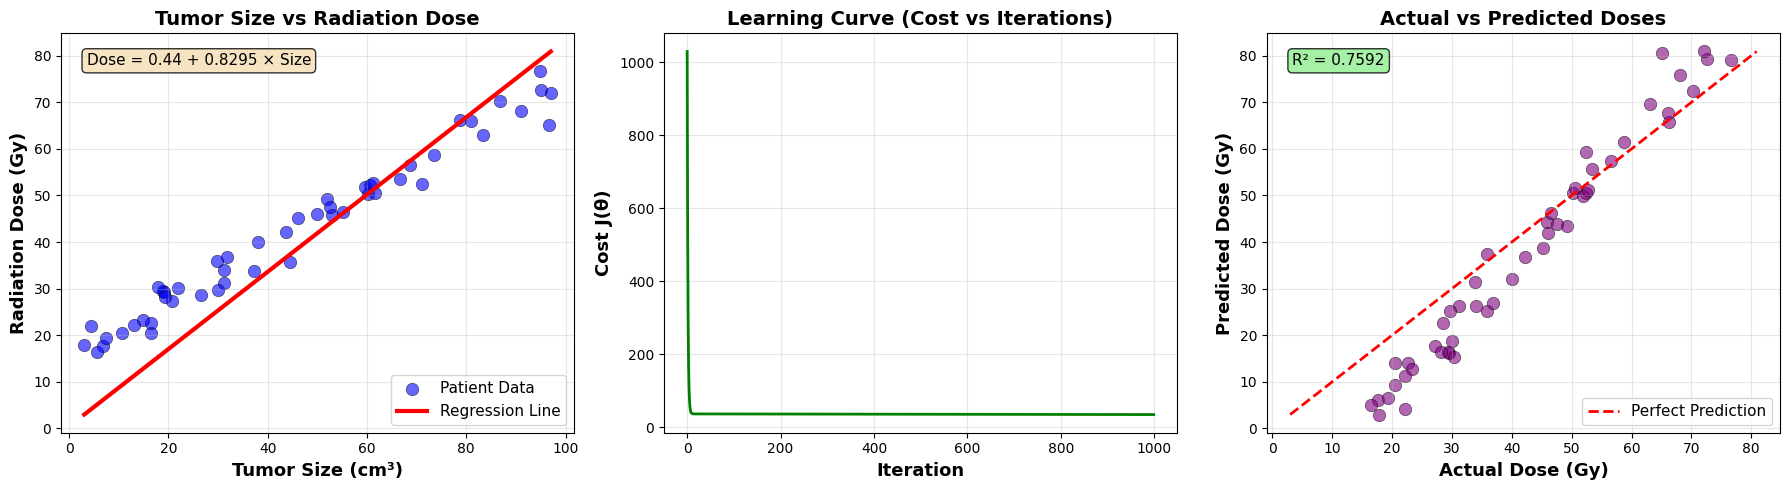


STEP 7: Clinical Interpretation
------------------------------------------------------------

📊 What does this mean?
   • Baseline dose: 0.44 Gy (minimum dose needed)
   • For every 1 cm³ increase in tumor size:
     dose increases by 0.8295 Gy

💡 Example:
   • A 20 cm³ tumor needs: 17.03 Gy
   • A 60 cm³ tumor needs: 50.21 Gy
   • Difference: 33.18 Gy

✓ ANALYSIS COMPLETE!


In [ ]:
"""
Simple Linear Regression for Tumor Size-Dose Prediction
Perfect for B.Tech Students - Easy to Understand!

Problem: Predict radiation dose from tumor size
Method: Linear Regression (y = mx + c)
"""

import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# STEP 1: CREATE SYNTHETIC DATA
# ============================================================================
print("=" * 60)
print("LINEAR REGRESSION: Tumor Size → Radiation Dose")
print("=" * 60)
print("\nSTEP 1: Creating Synthetic Data")
print("-" * 60)

# Set random seed for reproducibility
np.random.seed(42)

# Number of patients
n_patients = 50

# Generate tumor sizes (1 to 100 cm³)
tumor_size = np.random.uniform(1, 100, n_patients)

# True relationship: dose = 15 + 0.6 * tumor_size + noise
# This means: baseline dose is 15 Gy, and we add 0.6 Gy per cm³
true_intercept = 15
true_slope = 0.6
noise = np.random.normal(0, 3, n_patients)  # Add some random noise

dose = true_intercept + true_slope * tumor_size + noise

print(f"Number of patients: {n_patients}")
print(f"Tumor size range: {tumor_size.min():.1f} to {tumor_size.max():.1f} cm³")
print(f"Dose range: {dose.min():.1f} to {dose.max():.1f} Gy")
print(f"\nTrue equation: Dose = {true_intercept} + {true_slope} × Tumor_Size")

# ============================================================================
# STEP 2: INITIALIZE PARAMETERS
# ============================================================================
print("\n" + "=" * 60)
print("STEP 2: Initialize Parameters")
print("-" * 60)

# Start with random guesses
theta_0 = 0  # Intercept (c in y = mx + c)
theta_1 = 0  # Slope (m in y = mx + c)

learning_rate = 0.0001  # How big steps we take
iterations = 1000       # How many times we update

print(f"Initial θ₀ (intercept): {theta_0}")
print(f"Initial θ₁ (slope): {theta_1}")
print(f"Learning rate: {learning_rate}")
print(f"Iterations: {iterations}")

# ============================================================================
# STEP 3: GRADIENT DESCENT (TRAINING)
# ============================================================================
print("\n" + "=" * 60)
print("STEP 3: Training the Model (Gradient Descent)")
print("-" * 60)

cost_history = []  # Store cost values

for i in range(iterations):
    # Make predictions with current parameters
    predictions = theta_0 + theta_1 * tumor_size

    # Calculate errors
    errors = predictions - dose

    # Calculate cost (Mean Squared Error)
    cost = (1 / (2 * n_patients)) * np.sum(errors ** 2)
    cost_history.append(cost)

    # Update parameters using gradient descent
    theta_0_gradient = (1 / n_patients) * np.sum(errors)
    theta_1_gradient = (1 / n_patients) * np.sum(errors * tumor_size)

    theta_0 = theta_0 - learning_rate * theta_0_gradient
    theta_1 = theta_1 - learning_rate * theta_1_gradient

    # Print progress every 200 iterations
    if i % 200 == 0:
        print(f"Iteration {i:4d}: Cost = {cost:.2f}, θ₀ = {theta_0:.2f}, θ₁ = {theta_1:.4f}")

print(f"\nFinal Parameters:")
print(f"θ₀ (intercept) = {theta_0:.2f} Gy")
print(f"θ₁ (slope) = {theta_1:.4f} Gy/cm³")
print(f"\nLearned equation: Dose = {theta_0:.2f} + {theta_1:.4f} × Tumor_Size")

# ============================================================================
# STEP 4: MAKE PREDICTIONS
# ============================================================================
print("\n" + "=" * 60)
print("STEP 4: Testing the Model")
print("-" * 60)

# Test on some example tumor sizes
test_sizes = np.array([10, 30, 50, 70, 90])
predicted_doses = theta_0 + theta_1 * test_sizes

print(f"\n{'Tumor Size (cm³)':<20} {'Predicted Dose (Gy)':<25}")
print("-" * 45)
for size, pred_dose in zip(test_sizes, predicted_doses):
    print(f"{size:<20.0f} {pred_dose:<25.2f}")

# ============================================================================
# STEP 5: CALCULATE ACCURACY
# ============================================================================
print("\n" + "=" * 60)
print("STEP 5: Model Accuracy")
print("-" * 60)

# Predictions on training data
final_predictions = theta_0 + theta_1 * tumor_size

# Calculate R² Score (how well the model fits)
ss_total = np.sum((dose - np.mean(dose)) ** 2)
ss_residual = np.sum((dose - final_predictions) ** 2)
r2_score = 1 - (ss_residual / ss_total)

# Calculate Mean Squared Error
mse = np.mean((dose - final_predictions) ** 2)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2_score:.4f}")
print(f"\nInterpretation:")
print(f"  • R² = {r2_score:.2%} of variance explained by the model")
print(f"  • Model fits {'very well' if r2_score > 0.9 else 'well' if r2_score > 0.7 else 'moderately'}!")

# ============================================================================
# STEP 6: VISUALIZATIONS
# ============================================================================
print("\n" + "=" * 60)
print("STEP 6: Creating Visualizations")
print("-" * 60)

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ----------------
# Plot 1: Data and Regression Line
# ----------------
axes[0].scatter(tumor_size, dose, alpha=0.6, s=80, color='blue',
                edgecolors='black', linewidth=0.5, label='Patient Data')

# Create regression line
x_line = np.linspace(tumor_size.min(), tumor_size.max(), 100)
y_line = theta_0 + theta_1 * x_line
axes[0].plot(x_line, y_line, 'r-', linewidth=3, label='Regression Line')

axes[0].set_xlabel('Tumor Size (cm³)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Radiation Dose (Gy)', fontsize=13, fontweight='bold')
axes[0].set_title('Tumor Size vs Radiation Dose', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Add equation on plot
equation_text = f'Dose = {theta_0:.2f} + {theta_1:.4f} × Size'
axes[0].text(0.05, 0.95, equation_text, transform=axes[0].transAxes,
             fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# ----------------
# Plot 2: Cost Function History
# ----------------
axes[1].plot(cost_history, 'g-', linewidth=2)
axes[1].set_xlabel('Iteration', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Cost J(θ)', fontsize=13, fontweight='bold')
axes[1].set_title('Learning Curve (Cost vs Iterations)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# ----------------
# Plot 3: Actual vs Predicted
# ----------------
axes[2].scatter(dose, final_predictions, alpha=0.6, s=80, color='purple',
                edgecolors='black', linewidth=0.5)

# Perfect prediction line
min_val = min(dose.min(), final_predictions.min())
max_val = max(dose.max(), final_predictions.max())
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--',
             linewidth=2, label='Perfect Prediction')

axes[2].set_xlabel('Actual Dose (Gy)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Predicted Dose (Gy)', fontsize=13, fontweight='bold')
axes[2].set_title('Actual vs Predicted Doses', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

# Add R² score on plot
r2_text = f'R² = {r2_score:.4f}'
axes[2].text(0.05, 0.95, r2_text, transform=axes[2].transAxes,
             fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plt.savefig('linear_regression_results.png', dpi=150, bbox_inches='tight')
print("✓ Visualization saved as 'linear_regression_results.png'")
plt.show()

# ============================================================================
# STEP 7: CLINICAL INTERPRETATION
# ============================================================================
print("\n" + "=" * 60)
print("STEP 7: Clinical Interpretation")
print("-" * 60)
print(f"\n📊 What does this mean?")
print(f"   • Baseline dose: {theta_0:.2f} Gy (minimum dose needed)")
print(f"   • For every 1 cm³ increase in tumor size:")
print(f"     dose increases by {theta_1:.4f} Gy")
print(f"\n💡 Example:")
print(f"   • A 20 cm³ tumor needs: {theta_0 + theta_1*20:.2f} Gy")
print(f"   • A 60 cm³ tumor needs: {theta_0 + theta_1*60:.2f} Gy")
print(f"   • Difference: {(theta_0 + theta_1*60) - (theta_0 + theta_1*20):.2f} Gy")

print("\n" + "=" * 60)
print("✓ ANALYSIS COMPLETE!")
print("=" * 60)